# Hotel Booking Cancellation Prediction using Machine Learning

### Course Assignment(ise 3)
### Student Name: Sakshi Varma
### College: TCET
### Subject: Data Analytics / Machine Learning

---

## Objective

The objective of this project is to develop a machine learning model that predicts whether a hotel booking is likely to be cancelled. The prediction helps hotels reduce revenue loss, improve room allocation, and make better operational decisions.

---

## Business Problem

Hotels receive thousands of bookings every day. Many customers cancel their bookings before arrival, resulting in revenue loss and inefficient room management.

Using historical booking data, we aim to build a predictive model that can identify bookings that are likely to be cancelled.

In [ ]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.linear_model import LogisticRegression

# Model Evaluation
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [ ]:
df = pd.read_csv("bookings.csv")

In [ ]:
df.head()

,hotel,market_segment,deposit_type,lead_time,previous_cancellations,previous_bookings_not_canceled,days_in_waiting_list,booking_changes,total_of_special_requests,is_canceled
0,Resort Hotel,Direct,No Deposit,342,0,0,0,3,0,0
1,Resort Hotel,Direct,No Deposit,737,0,0,0,4,0,0
2,Resort Hotel,Direct,No Deposit,7,0,0,0,0,0,0
3,Resort Hotel,Corporate,No Deposit,13,0,0,0,0,0,0
4,Resort Hotel,Online TA,No Deposit,14,0,0,0,0,1,0


In [ ]:
df.shape

(119390, 10)

In [ ]:
df.columns

Index(['hotel', 'market_segment', 'deposit_type', 'lead_time',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'days_in_waiting_list', 'booking_changes', 'total_of_special_requests',
       'is_canceled'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 10 columns):
 #   Column                          Non-Null Count   Dtype 
---  ------                          --------------   ----- 
 0   hotel                           119390 non-null  object
 1   market_segment                  119390 non-null  object
 2   deposit_type                    119390 non-null  object
 3   lead_time                       119390 non-null  int64 
 4   previous_cancellations          119390 non-null  int64 
 5   previous_bookings_not_canceled  119390 non-null  int64 
 6   days_in_waiting_list            119390 non-null  int64 
 7   booking_changes                 119390 non-null  int64 
 8   total_of_special_requests       119390 non-null  int64 
 9   is_canceled                     119390 non-null  int64 
dtypes: int64(7), object(3)
memory usage: 9.1+ MB


In [ ]:
df.describe()

,lead_time,previous_cancellations,previous_bookings_not_canceled,days_in_waiting_list,booking_changes,total_of_special_requests,is_canceled
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,104.011416,0.087118,0.137097,2.321149,0.221124,0.571363,0.370416
std,106.863097,0.844336,1.497437,17.594721,0.652306,0.792798,0.482918
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,69.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,160.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,737.000000,26.000000,72.000000,391.000000,21.000000,5.000000,1.000000


In [ ]:
df.isnull().sum()

,0
hotel,0
market_segment,0
deposit_type,0
lead_time,0
previous_cancellations,0
previous_bookings_not_canceled,0
days_in_waiting_list,0
booking_changes,0
total_of_special_requests,0
is_canceled,0


Class Distribution

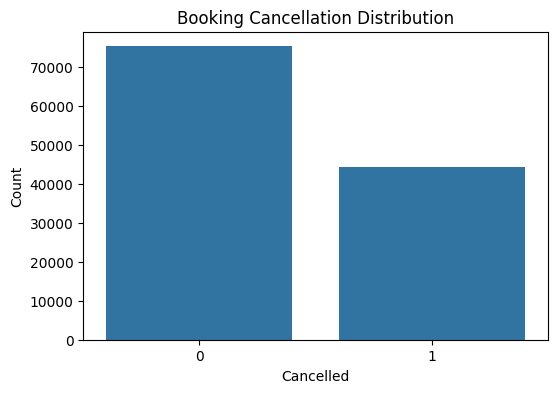

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x='is_canceled', data=df)

plt.title("Booking Cancellation Distribution")

plt.xlabel("Cancelled")

plt.ylabel("Count")

plt.show()

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the characteristics of the dataset, identify relationships between variables, detect patterns, and gain business insights before building the machine learning model.

1. Target Variable Distribution

/tmp/ipykernel_5777/4277083508.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Cancelled (0)', 'Cancelled (1)'])


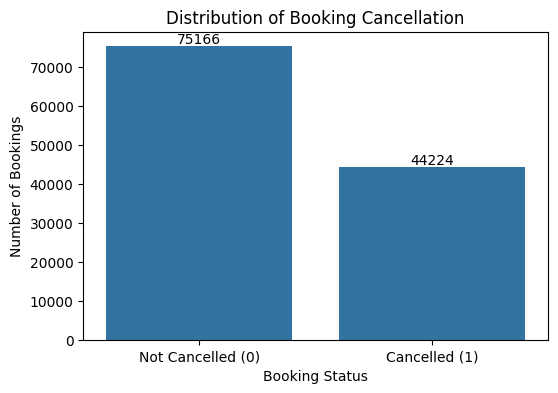

In [ ]:
plt.figure(figsize=(6,4))

ax = sns.countplot(x='is_canceled', data=df)

plt.title("Distribution of Booking Cancellation")
plt.xlabel("Booking Status")
plt.ylabel("Number of Bookings")

ax.set_xticklabels(['Not Cancelled (0)', 'Cancelled (1)'])

for container in ax.containers:
    ax.bar_label(container)

plt.show()

2. Hotel Type vs Cancellation

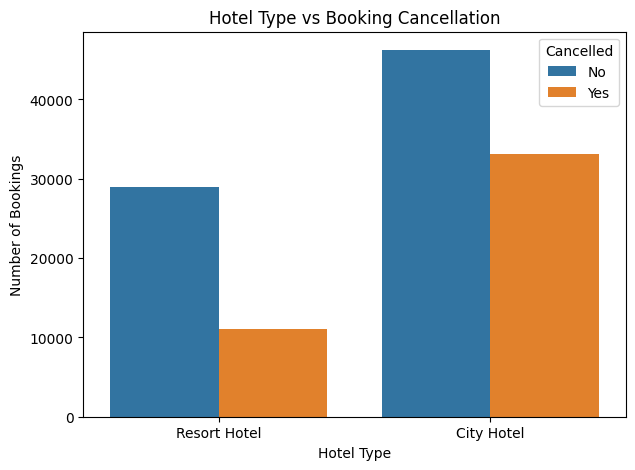

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='hotel',
    hue='is_canceled',
    data=df
)

plt.title("Hotel Type vs Booking Cancellation")
plt.xlabel("Hotel Type")
plt.ylabel("Number of Bookings")

plt.legend(title="Cancelled", labels=["No","Yes"])

plt.show()

3. Market Segment vs Cancellation

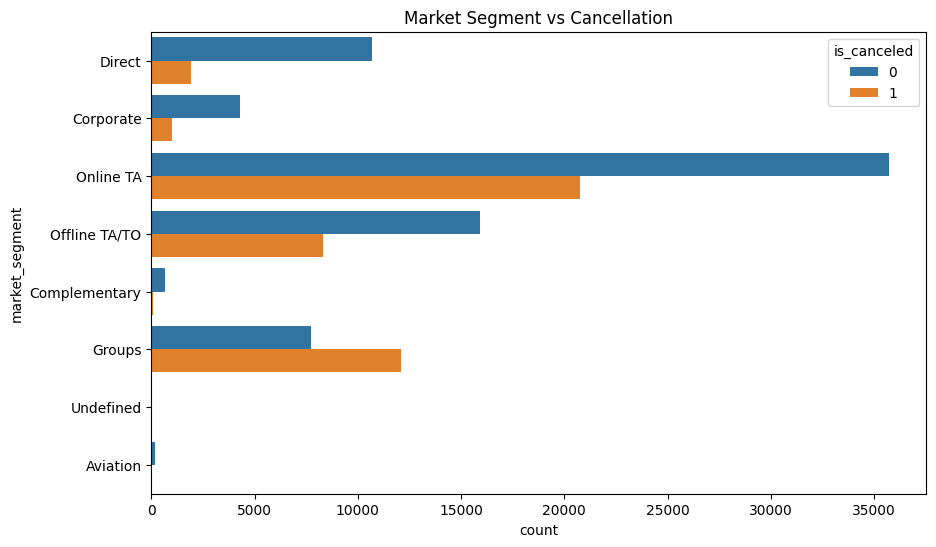

In [ ]:
plt.figure(figsize=(10,6))

sns.countplot(
    y='market_segment',
    hue='is_canceled',
    data=df
)

plt.title("Market Segment vs Cancellation")

plt.show()

4. Deposit Type vs Cancellation

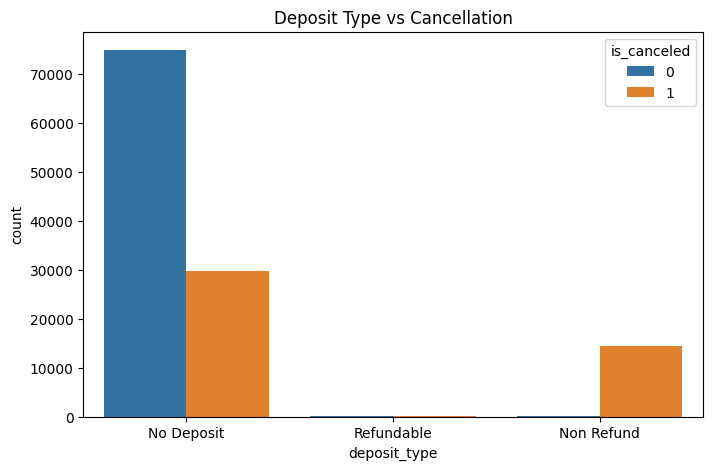

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='deposit_type',
    hue='is_canceled',
    data=df
)

plt.title("Deposit Type vs Cancellation")

plt.show()

5. Lead Time Distribution

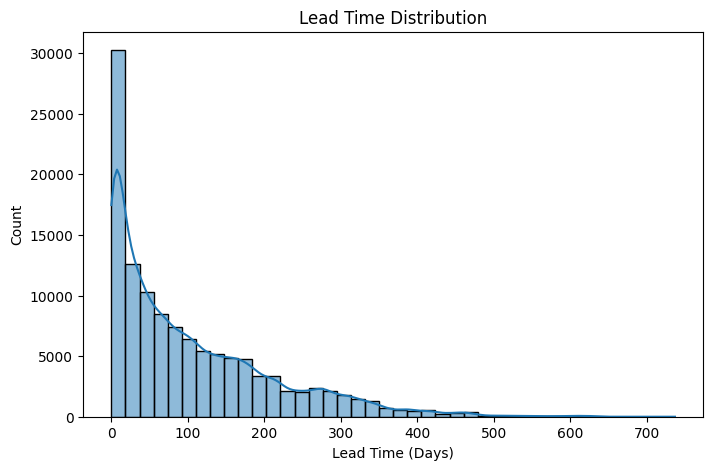

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['lead_time'],
    bins=40,
    kde=True
)

plt.title("Lead Time Distribution")

plt.xlabel("Lead Time (Days)")

plt.show()

6. Previous Cancellations

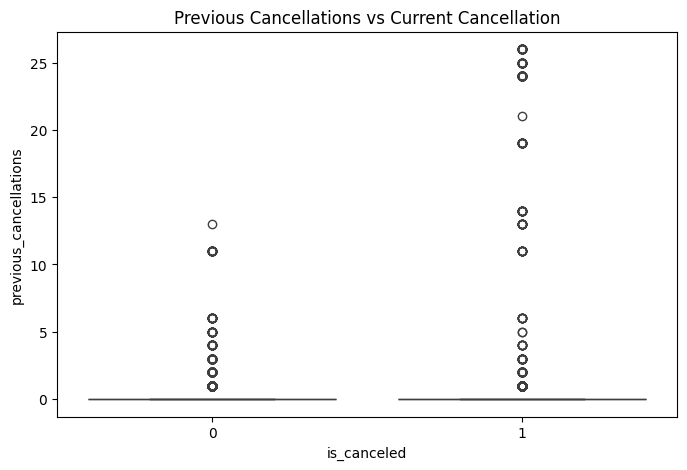

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='is_canceled',
    y='previous_cancellations',
    data=df
)

plt.title("Previous Cancellations vs Current Cancellation")

plt.show()

7. Booking Changes

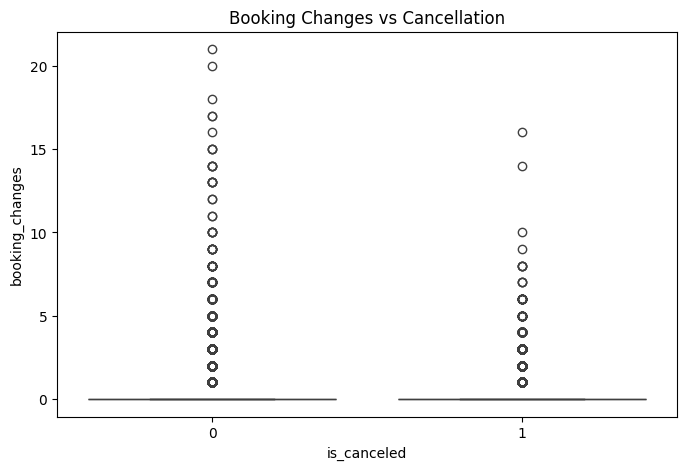

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='is_canceled',
    y='booking_changes',
    data=df
)

plt.title("Booking Changes vs Cancellation")

plt.show()

8. Special Requests

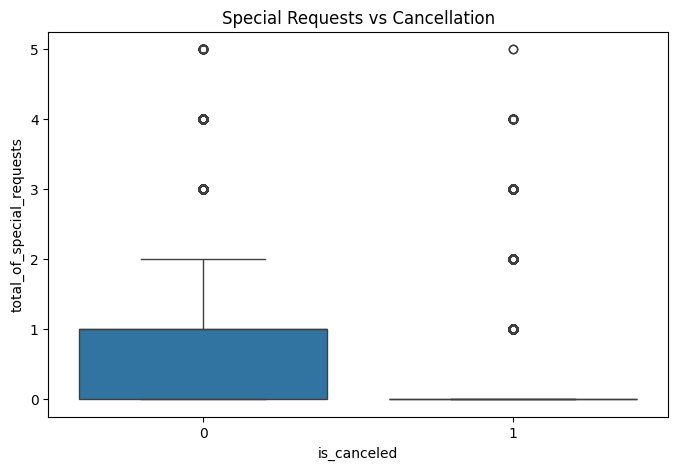

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='is_canceled',
    y='total_of_special_requests',
    data=df
)

plt.title("Special Requests vs Cancellation")

plt.show()

9. Correlation Heatmap

In [ ]:
numeric_df = df.select_dtypes(include=['int64','float64'])

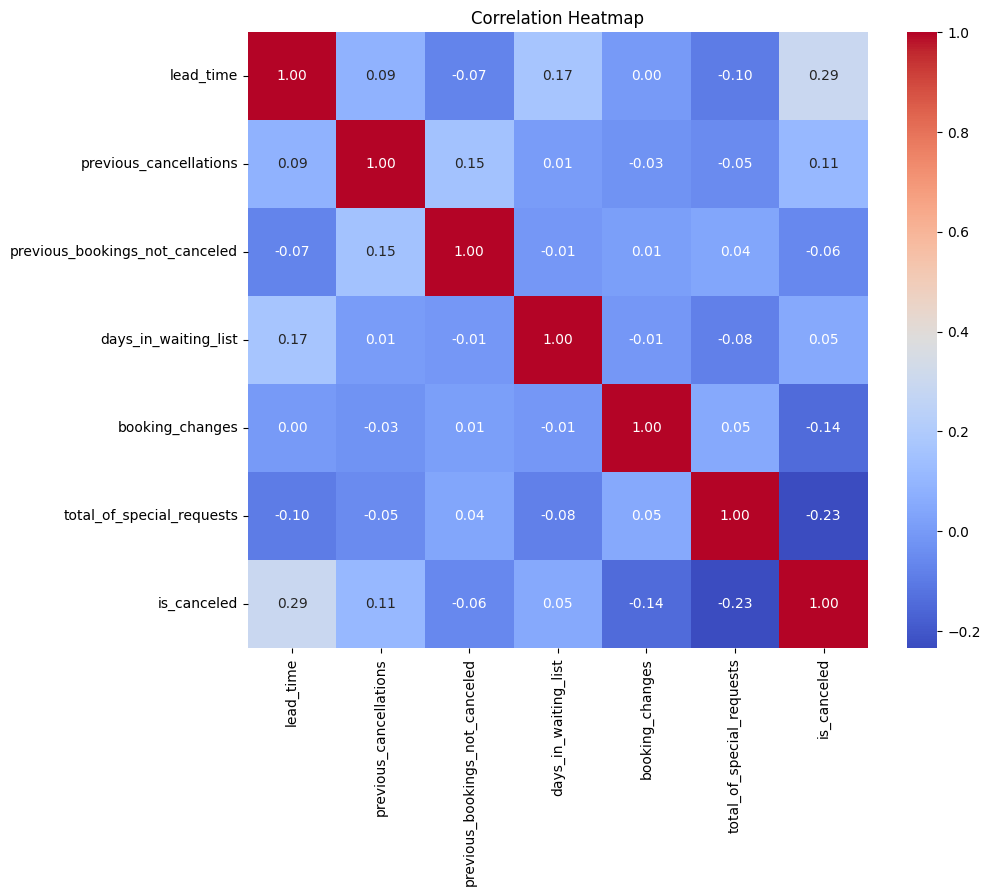

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

10. percentages to the Target Distribution

In [ ]:
cancel_percent = df['is_canceled'].value_counts(normalize=True) * 100
print(cancel_percent)

is_canceled
0    62.958372
1    37.041628
Name: proportion, dtype: float64


Cancellation Rate by Hotel Type (%)

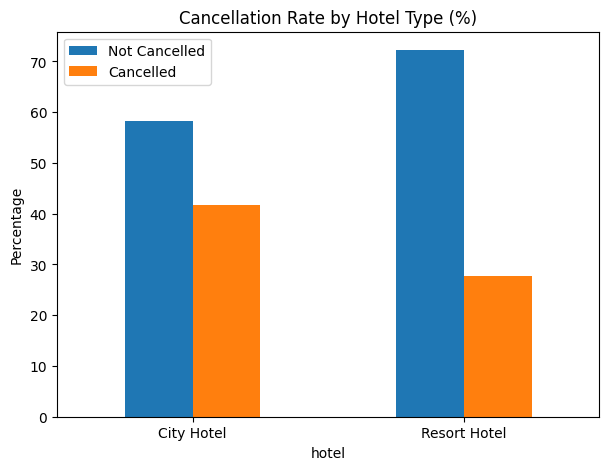

In [ ]:
hotel_cancel_rate = pd.crosstab(
    df['hotel'],
    df['is_canceled'],
    normalize='index'
) * 100

hotel_cancel_rate.plot(
    kind='bar',
    figsize=(7,5)
)

plt.title("Cancellation Rate by Hotel Type (%)")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(["Not Cancelled","Cancelled"])
plt.show()

## Overall Findings from Exploratory Data Analysis

The exploratory data analysis revealed several important patterns related to hotel booking cancellations.

- Approximately 37% of bookings were cancelled.
- City Hotels experienced more cancellations than Resort Hotels.
- Online Travel Agencies generated the highest number of cancellations.
- Deposit type appeared to have a strong relationship with cancellation behavior.
- Customers with longer lead times were more likely to cancel.
- Previous cancellation history increased the probability of future cancellations.
- Customers making more special requests or booking changes were less likely to cancel.


# Data Preprocessing & Feature Engineering

In [37]:
df.dtypes

,0
hotel,object
market_segment,object
deposit_type,object
lead_time,int64
previous_cancellations,int64
previous_bookings_not_canceled,int64
days_in_waiting_list,int64
booking_changes,int64
total_of_special_requests,int64
is_canceled,int64


In [38]:
X = df.drop("is_canceled", axis=1)
y = df["is_canceled"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (119390, 9)
Target Shape: (119390,)


In [39]:
## categorical data

X.select_dtypes(include="object").columns

Index(['hotel', 'market_segment', 'deposit_type'], dtype='object')

Encode Categorical Variable

In [40]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

categorical_columns = X.select_dtypes(include='object').columns

for column in categorical_columns:
    X[column] = label_encoder.fit_transform(X[column])

X.head()

,hotel,market_segment,deposit_type,lead_time,previous_cancellations,previous_bookings_not_canceled,days_in_waiting_list,booking_changes,total_of_special_requests
0,1,3,0,342,0,0,0,3,0
1,1,3,0,737,0,0,0,4,0
2,1,3,0,7,0,0,0,0,0
3,1,2,0,13,0,0,0,0,0
4,1,6,0,14,0,0,0,0,1


In [41]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 9 columns):
 #   Column                          Non-Null Count   Dtype
---  ------                          --------------   -----
 0   hotel                           119390 non-null  int64
 1   market_segment                  119390 non-null  int64
 2   deposit_type                    119390 non-null  int64
 3   lead_time                       119390 non-null  int64
 4   previous_cancellations          119390 non-null  int64
 5   previous_bookings_not_canceled  119390 non-null  int64
 6   days_in_waiting_list            119390 non-null  int64
 7   booking_changes                 119390 non-null  int64
 8   total_of_special_requests       119390 non-null  int64
dtypes: int64(9)
memory usage: 8.2 MB


Train-Test Split

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [44]:
print("Training Features :", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Labels :", y_train.shape)
print("Testing Labels :", y_test.shape)

Training Features : (95512, 9)
Testing Features : (23878, 9)
Training Labels : (95512,)
Testing Labels : (23878,)


In [45]:
encoded_df = X.copy()
encoded_df["is_canceled"] = y

encoded_df.to_csv("encoded_bookings.csv", index=False)

# Model Building

1. Logistic Regression

In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

lr = LogisticRegression(max_iter=1000, random_state=42)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, lr_pred))

print("\nClassification Report\n")
print(classification_report(y_test, lr_pred))

Accuracy: 0.7816400033503643

Classification Report

              precision    recall  f1-score   support

           0       0.75      0.98      0.85     15033
           1       0.93      0.45      0.60      8845

    accuracy                           0.78     23878
   macro avg       0.84      0.71      0.73     23878
weighted avg       0.82      0.78      0.76     23878



Confusion Matrix

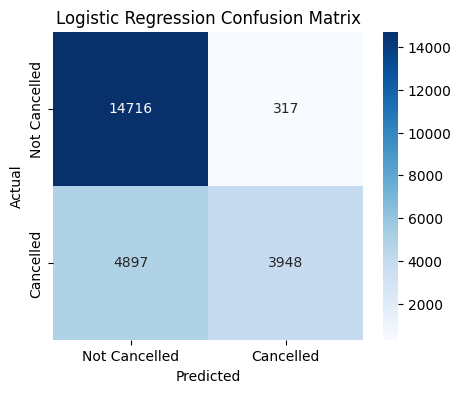

In [47]:
cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Not Cancelled','Cancelled'],
            yticklabels=['Not Cancelled','Cancelled'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

2. Decision Tree

In [50]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, dt_pred))

print("\nClassification Report\n")
print(classification_report(y_test, dt_pred))

Accuracy: 0.8058463857944551

Classification Report

              precision    recall  f1-score   support

           0       0.82      0.89      0.85     15033
           1       0.78      0.66      0.72      8845

    accuracy                           0.81     23878
   macro avg       0.80      0.78      0.78     23878
weighted avg       0.80      0.81      0.80     23878



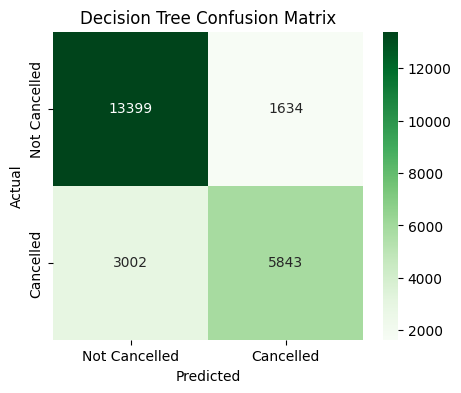

In [51]:
cm = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Greens',
            xticklabels=['Not Cancelled','Cancelled'],
            yticklabels=['Not Cancelled','Cancelled'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")

plt.show()

3: Random Forest

In [52]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_pred))

print("\nClassification Report\n")
print(classification_report(y_test, rf_pred))

Accuracy: 0.8077309657425245

Classification Report

              precision    recall  f1-score   support

           0       0.82      0.89      0.85     15033
           1       0.78      0.67      0.72      8845

    accuracy                           0.81     23878
   macro avg       0.80      0.78      0.79     23878
weighted avg       0.81      0.81      0.80     23878



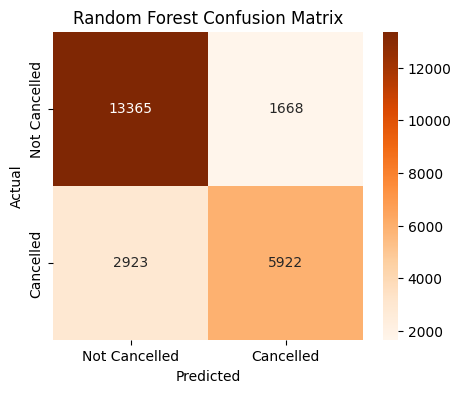

In [53]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Oranges',
            xticklabels=['Not Cancelled','Cancelled'],
            yticklabels=['Not Cancelled','Cancelled'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

Comparison of All Models

In [54]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ]
})

results = results.sort_values(by="Accuracy", ascending=False)

results

,Model,Accuracy
2,Random Forest,0.807731
1,Decision Tree,0.805846
0,Logistic Regression,0.781640


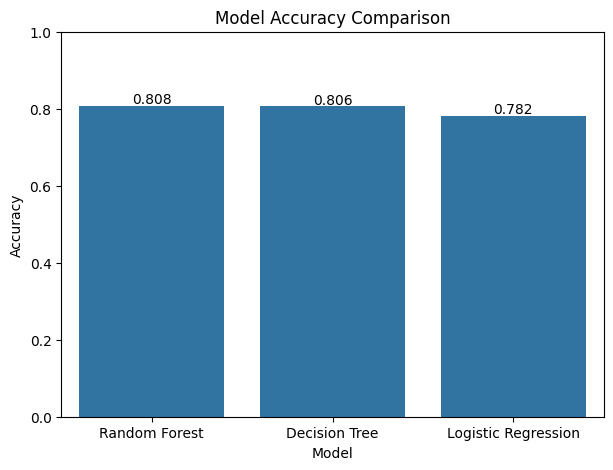

In [55]:
# accuracy bar graph....

plt.figure(figsize=(7,5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")

plt.ylim(0,1)

for index, value in enumerate(results["Accuracy"]):
    plt.text(index, value+0.005, f"{value:.3f}", ha='center')

plt.show()

In [57]:
# feature importance....

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
3,lead_time,0.353467
2,deposit_type,0.305665
1,market_segment,0.107363
8,total_of_special_requests,0.088047
4,previous_cancellations,0.073549
7,booking_changes,0.039732
5,previous_bookings_not_canceled,0.013478
0,hotel,0.011291
6,days_in_waiting_list,0.007407


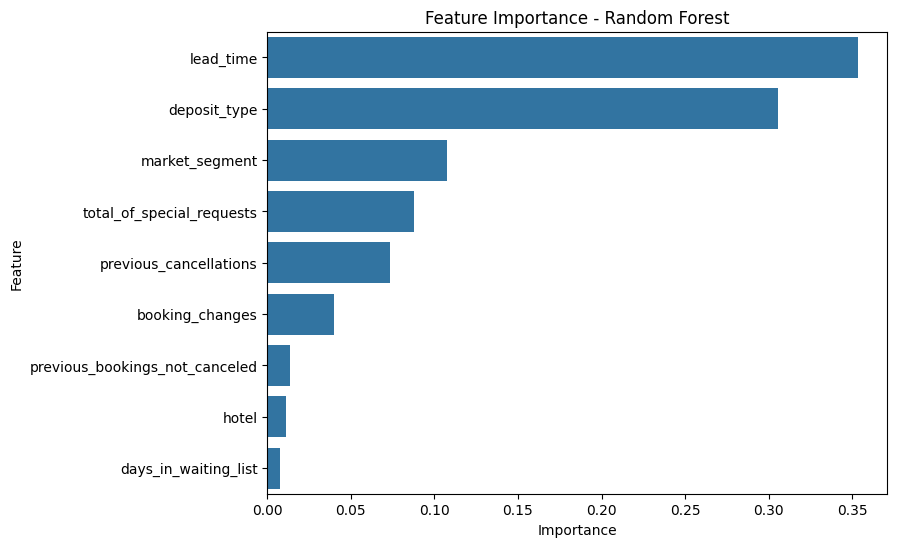

In [58]:
# plot of feature importance ...
plt.figure(figsize=(8,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance - Random Forest")

plt.show()

# Interpretation of Prediction Results

The Random Forest model achieved the highest accuracy among the evaluated models.

The model successfully identified most cancelled and non-cancelled bookings.

This indicates that booking characteristics such as lead time, deposit type, previous cancellations, booking changes, and special requests provide useful information for predicting hotel booking cancellations.

The model can assist hotel management in identifying high-risk bookings and taking preventive actions.

In [59]:
from sklearn.metrics import precision_score, recall_score, f1_score

comparison = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy":[
        accuracy_score(y_test,lr_pred),
        accuracy_score(y_test,dt_pred),
        accuracy_score(y_test,rf_pred)
    ],
    "Precision":[
        precision_score(y_test,lr_pred),
        precision_score(y_test,dt_pred),
        precision_score(y_test,rf_pred)
    ],
    "Recall":[
        recall_score(y_test,lr_pred),
        recall_score(y_test,dt_pred),
        recall_score(y_test,rf_pred)
    ],
    "F1 Score":[
        f1_score(y_test,lr_pred),
        f1_score(y_test,dt_pred),
        f1_score(y_test,rf_pred)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.781640,0.925674,0.446354,0.602288
1,Decision Tree,0.805846,0.781463,0.660599,0.715966
2,Random Forest,0.807731,0.780237,0.669531,0.720657


# Interpretation of Prediction Results

Three machine learning models were trained and evaluated for predicting hotel booking cancellations.

Among all models, Random Forest achieved the highest prediction accuracy of approximately 80.8%, followed closely by Decision Tree (80.6%) and Logistic Regression (78.2%).

The Random Forest model successfully captured complex relationships among booking attributes such as lead time, deposit type, market segment, and previous cancellations.

Although the improvement in accuracy over Decision Tree is relatively small, Random Forest is generally more robust because it combines predictions from multiple decision trees, reducing overfitting and improving generalization.

Therefore, Random Forest was selected as the final prediction model.

# Feature Importance Analysis

Random Forest provides feature importance scores indicating which variables contribute most to predicting booking cancellations.

The most influential features are:

• Lead Time (35.3%)
• Deposit Type (30.6%)
• Market Segment (10.7%)
• Total Special Requests (8.8%)
• Previous Cancellations (7.4%)

These findings suggest that customers who book far in advance, choose specific deposit policies, and belong to particular market segments are more likely to cancel their bookings.

# Error Analysis

Although the Random Forest model achieved an accuracy of approximately 80.8%, prediction errors still occurred.

Possible reasons include:

• Some customers cancel bookings due to unexpected personal reasons that are not captured in the dataset.

• External factors such as weather conditions, flight cancellations, medical emergencies, or economic situations are unavailable.

• Similar booking patterns may belong to customers with different cancellation behavior.

• The reduced dataset contains only selected booking attributes, limiting the model's ability to capture all influencing factors.

False Positive:
The model predicts a booking will be cancelled even though the customer arrives.

False Negative:
The model predicts the booking will not be cancelled, but the customer cancels.

Reducing false negatives is especially important because hotels may lose opportunities to prepare for cancelled bookings.

# Model Bias and Limitations

The model has several limitations.

• The dataset contains more City Hotel bookings than Resort Hotel bookings, which may influence learning.

• Most bookings belong to Online Travel Agencies, causing unequal representation of market segments.

• Customer demographic information is unavailable.

• Economic conditions, holidays, weather, and travel restrictions are not included.

• Duplicate booking patterns may exist because only selected features are available.

Therefore, predictions should be interpreted as decision support rather than absolute truth.

# Feature Improvement Recommendations

The predictive performance can be improved by incorporating additional features such as:

• Customer loyalty membership
• Weather conditions
• Public holidays
• Flight status
• Customer review history
• Number of previous stays
• Room type
• Booking platform
• Local events and festivals
• Customer income or travel purpose (if available)

Including these features may improve prediction accuracy and reduce classification errors.

# Ethical Considerations

The development of AI-based hotel booking prediction systems should follow responsible AI principles.

• Customer personal information must remain confidential.

• Data should be collected with proper consent.

• The model should not discriminate against customers based on nationality, gender, or other protected characteristics.

• Prediction results should assist hotel staff rather than automatically reject bookings.

• Regular audits should be conducted to identify bias and ensure fairness.

• Customer data must be securely stored and encrypted.

# Deployment Challenges

Deploying the model in a real hotel environment introduces several practical challenges.

• Customer behavior changes over time (Data Drift).

• The model must process thousands of bookings efficiently.

• Missing or incomplete booking information may reduce prediction quality.

• The system must integrate with existing hotel management software.

• The model should be retrained periodically using new booking data.

• Continuous monitoring is necessary to maintain prediction accuracy.

# Conclusion

This project successfully developed a machine learning model capable of predicting hotel booking cancellations.

Three classification algorithms were evaluated, and Random Forest achieved the highest accuracy of approximately 80.8%.

Exploratory Data Analysis identified important factors influencing cancellation, including lead time, deposit type, market segment, previous cancellations, and special requests.

The findings demonstrate that machine learning can effectively assist hotels in reducing revenue loss, improving room allocation, and supporting operational decision-making.

Future work may include integrating additional real-world features and deploying the model as a web-based decision support system for hotel managers.

# Reflective Learning

Working on this project provided practical experience similar to that of a data scientist in the hospitality industry.

Beyond building a predictive model, the project emphasized understanding business problems, analyzing customer behavior, interpreting model outputs, identifying limitations, and considering ethical implications.

This experience demonstrated that successful machine learning projects require not only high prediction accuracy but also careful interpretation, fairness, and practical deployment planning.

The project strengthened my skills in data preprocessing, exploratory data analysis, feature engineering, machine learning model development, model evaluation, and business-oriented decision making.

Something more relevant ....

ROC Curve


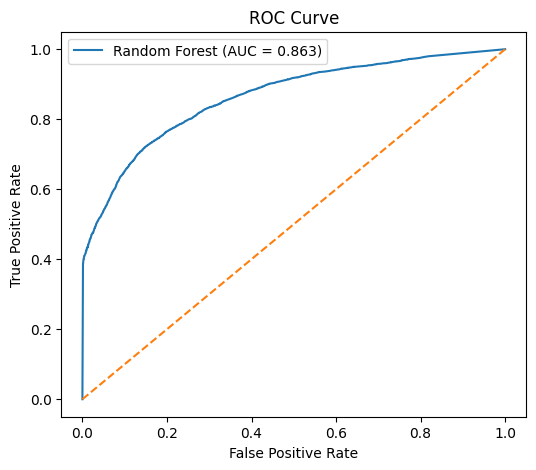

In [60]:
from sklearn.metrics import roc_curve, auc

rf_prob = rf.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, rf_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

Actual vs Predicted

In [61]:
prediction_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": rf_pred
})

prediction_df.head(20)

,Actual,Predicted
0,0,0
1,0,0
2,1,1
3,0,0
4,0,0
5,1,1
6,1,1
7,0,1
8,0,0
9,0,0


Misclassified Records

In [62]:
prediction_df = X_test.copy()

prediction_df["Actual"] = y_test.values
prediction_df["Predicted"] = rf_pred

errors = prediction_df[prediction_df["Actual"] != prediction_df["Predicted"]]

print("Number of Incorrect Predictions:", len(errors))

errors.head(10)

Number of Incorrect Predictions: 4591


,hotel,market_segment,deposit_type,lead_time,previous_cancellations,previous_bookings_not_canceled,days_in_waiting_list,booking_changes,total_of_special_requests,Actual,Predicted
48445,0,6,0,82,0,0,0,0,0,0,1
68857,0,6,0,29,0,0,0,0,4,1,0
110682,0,6,0,110,0,0,0,0,0,0,1
73629,0,6,0,35,0,0,0,0,1,1,0
60040,0,6,0,121,0,0,0,0,1,1,0
83995,0,6,0,13,0,0,0,0,0,0,1
55835,0,6,0,138,0,0,0,0,1,1,0
64259,0,6,0,141,0,0,0,0,2,1,0
69746,0,6,0,7,0,0,0,0,1,1,0
61154,0,6,0,37,0,0,0,0,1,1,0


In [63]:
import joblib

joblib.dump(rf, "hotel_booking_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [64]:
# let's predict a new booking ....
sample_booking = pd.DataFrame({
    "hotel":[0],
    "market_segment":[4],
    "deposit_type":[0],
    "lead_time":[120],
    "previous_cancellations":[1],
    "previous_bookings_not_canceled":[2],
    "days_in_waiting_list":[0],
    "booking_changes":[1],
    "total_of_special_requests":[2]
})

prediction = rf.predict(sample_booking)

if prediction[0] == 1:
    print("Prediction: Booking is likely to be Cancelled")
else:
    print("Prediction: Booking is likely to be Completed")

Prediction: Booking is likely to be Cancelled


In [65]:
comparison.to_csv("model_comparison.csv", index=False)
importance.to_csv("feature_importance.csv", index=False)
prediction_df.to_csv("prediction_results.csv", index=False)